In [44]:
import math
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
import nnx
import nnx.functional as Fx
import nnx.graphics as G
import nnx.console as console
import nnx.projection as P

def random_color_map(x):
    remapping = G.DEFAULT_PALETTE[F.pad(torch.randperm(len(G.DEFAULT_PALETTE)-1)+1, (1,0))]
    return G.palette_to_rgb(x, remapping)

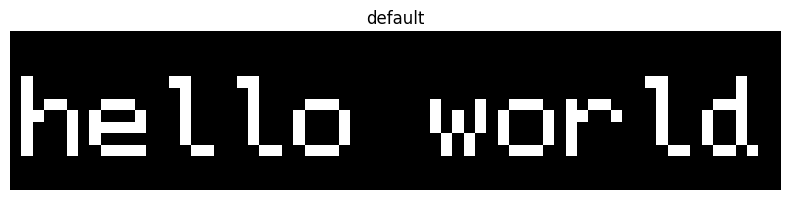

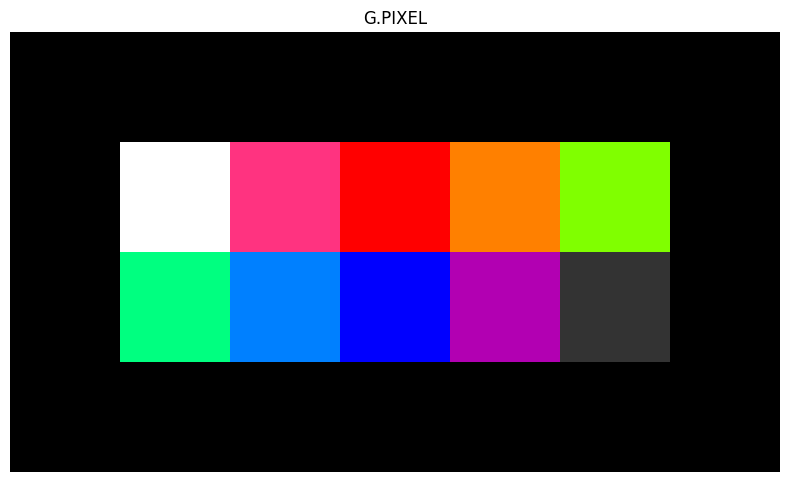

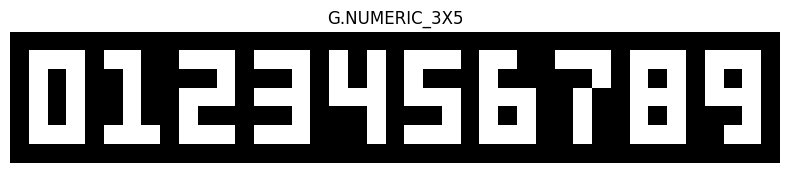

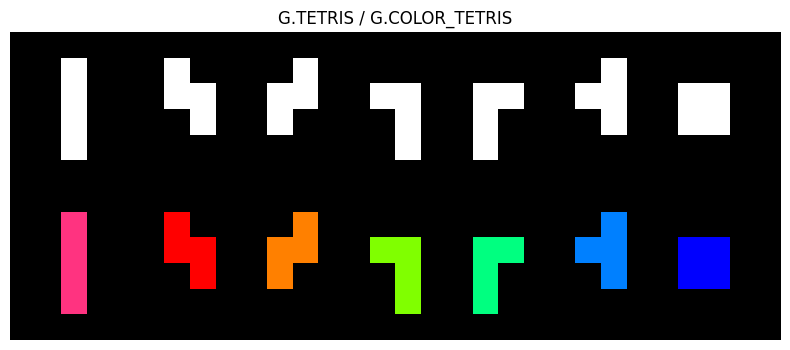

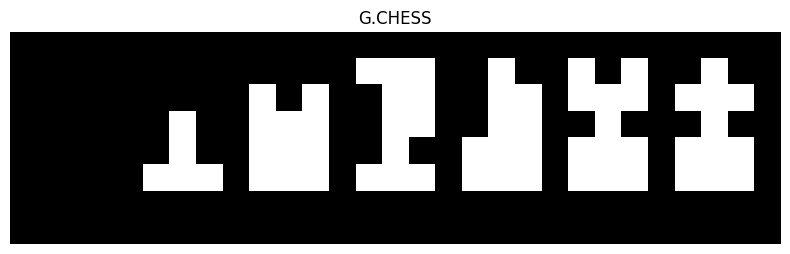

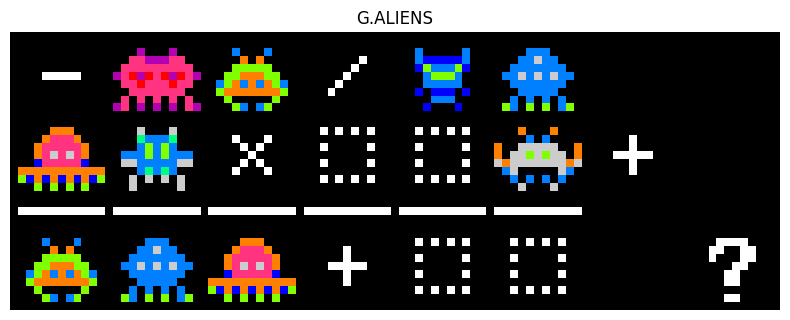

In [2]:
image = G.render_text("hello world")
G.plot(image, width=10, title="default")


image = G.render_text("01234\n56789", font=G.PIXEL, colorspace="rgb")
G.plot(image, width=10, title="G.PIXEL")


image = G.render_text("0123456789", font=G.NUMERIC_5X3, spacing=1)
G.plot(image, width=10, title="G.NUMERIC_3X5")


image_mono = G.render_text("0123456", font=G.TETRIS, colorspace="rgb")
image_color = G.render_text("0123456", font=G.COLOR_TETRIS, colorspace="rgb")
image = torch.cat([image_mono, image_color],-2)
G.plot(image, width=10, title="G.TETRIS / G.COLOR_TETRIS")


image = G.render_text(".prnbqk", font=G.CHESS, spacing=1)
G.plot(image, width=10, title="G.CHESS")

image = G.render_text("-12/34 \n56*##9+\n______\n245+## ?", font=G.ALIENS, spacing=1, colorspace="rgb")
G.plot(image, width=10, title="G.ALIENS")

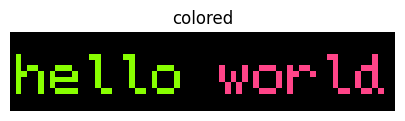

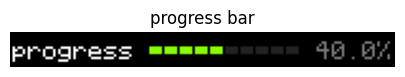

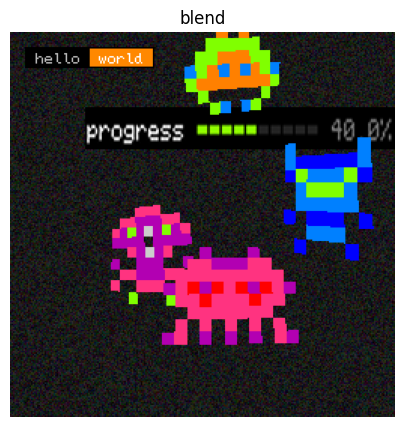

In [138]:
image = G.render_text("<lime>hello <pink>world</>")
G.plot(image, width=5, title="colored")

progress = console.ProgressBar(100, title="progress")
progress.value = 40
progress = G.render_text(progress)
G.plot(progress, width=5, title="progress bar")

image = G.render_text("<#BBB> hello <white~orange> world </>")
dst = torch.rand(3,256,256)*0.2
dst = G.blend(dst, image, (10,10), mode="bicubic")
dst = G.blend(dst, progress, (50,50,50+progress.shape[-2]*2,50+progress.shape[-1]*2), mode="bicubic")


for i in range(4):
    image = G.render_text(i, font=G.ALIENS)
    matrix = torch.eye(3) * 3 + torch.randn(3,3) * 0.2
    matrix[:2,-1] = torch.randn(2)*2
    matrix[-1,-1]=1
    matrix = P.unshear(matrix)
    dst = G.blend(dst, image, matrix, alpha=(0,0,0.), mode="nearest")
G.plot(dst, width=5, title="blend")

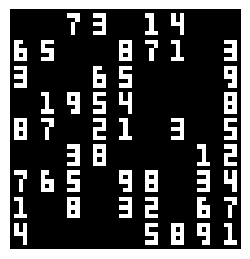

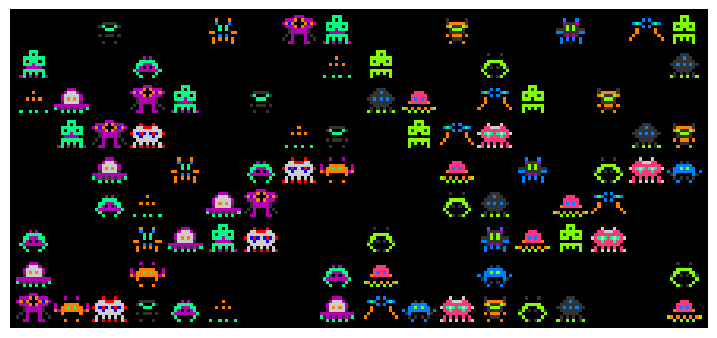

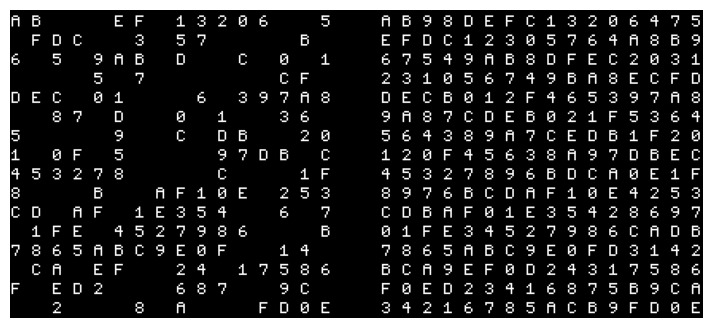

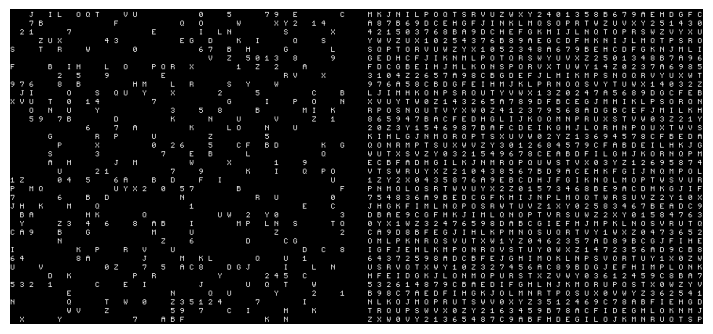

In [131]:
from nnx.graphics.sudoku import render_sudoku
import random
import copy
challenge, solution = render_sudoku()
G.plot(challenge, width=3)

challenge, solution = render_sudoku(spacing=(2,1), difficulty=0.5, font=G.ALIENS, colorspace="palette")
challenge_a = random_color_map(challenge)
challenge_b = random_color_map(challenge)
G.plot(torch.stack([challenge_a, challenge_b]), width=9)

challenge, solution = render_sudoku(4, spacing=(0,7),font=G.DEFAULT)
image = torch.cat([challenge, torch.zeros(1,challenge.shape[-2], 30, device=challenge.device), solution],-1)
G.plot(image, width=9)

challenge, solution = render_sudoku(6, spacing=(0,7), difficulty=0.7, font=G.DEFAULT)
image = torch.cat([challenge, torch.zeros(1,challenge.shape[-2], 30, device=challenge.device), solution],-1)
G.plot(image, width=9)



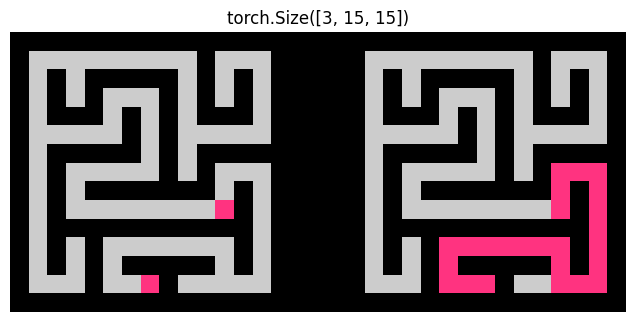

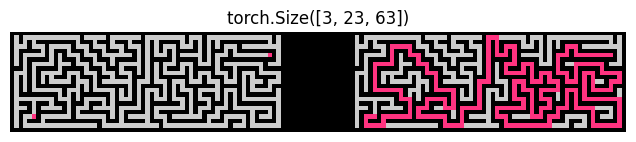

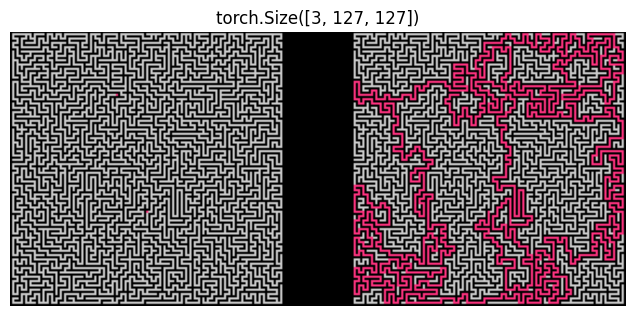

In [5]:
from nnx.graphics.maze import render_maze

challenge, solution = render_maze((8,8), colorspace="rgb")
image = torch.cat([challenge, torch.zeros(*challenge.shape[:-1], challenge.shape[-1]//4, device=challenge.device), solution],-1)
G.plot(image, title=str(challenge.shape), width=8)

challenge, solution = render_maze((12,32),colorspace="rgb")
image = torch.cat([challenge, torch.zeros(*challenge.shape[:-1], challenge.shape[-1]//4, device=challenge.device), solution],-1)
G.plot(image, title=str(challenge.shape), width=8)

challenge, solution = render_maze((64,64),colorspace="rgb")
image = torch.cat([challenge, torch.zeros(*challenge.shape[:-1], challenge.shape[-1]//4, device=challenge.device), solution],-1)
G.plot(image, title=str(challenge.shape), width=8)



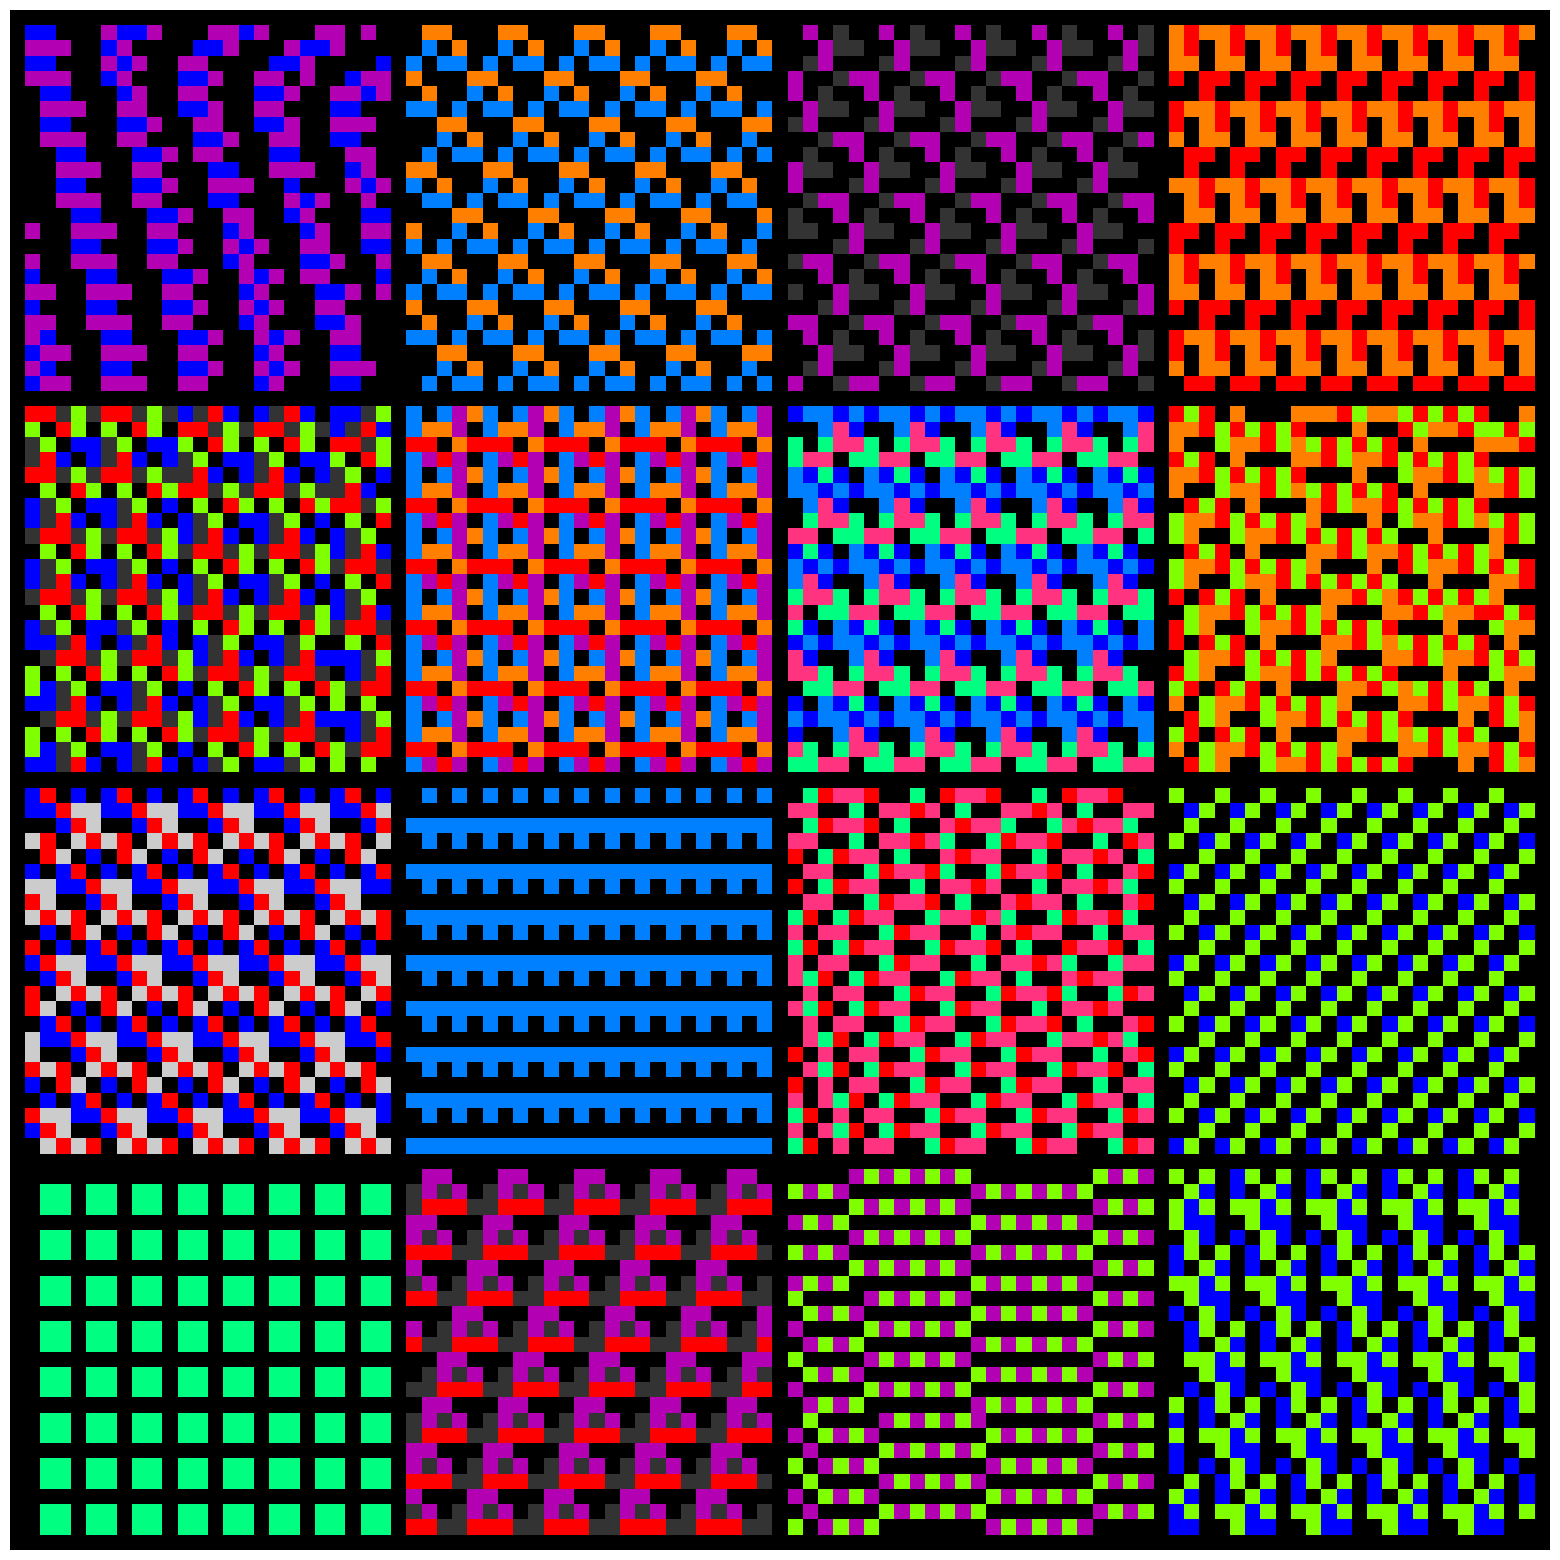

In [6]:
from nnx.graphics.pattern import render_random_pattern

image = torch.stack([random_color_map(render_random_pattern((24,24))) for _ in range(16)]) 
G.plot(image, cols=4)

REMEMBER RESONATOR IS STABLE EVEN WHEN NOISE ADDED TO COEFFS. So it could be evolved, or coeffs could be predicted by another model

In [7]:
# Can a resonator predict a resonator based on its (input / output) -> [INPUT/OUTPUT] > predictor > [PARAMETERS]